In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Figure 1, Figure S2 Country-level disparity

In [2]:
COLOR_ENGLISH = "#62a0cb"
COLOR_NON_ENGLISH = "#ffa556"
COLOR_SCATTER_GERMANIC = "#e377c2"
COLOR_SCATTER_INDOEU = "#7f7f7f"
COLOR_SCATTER_NON_INDOEU = "#17becf"
SCATTER_TYPE_COLOR_MAP = {
    "Germanic (excl. English)": COLOR_SCATTER_GERMANIC,
    "Other Indo-European": COLOR_SCATTER_INDOEU,
    "Non Indo-European": COLOR_SCATTER_NON_INDOEU,
}
COLOR_SCATTER_REG_LINE = "#a6cee3"
COLOR_SCATTER_REG_BAND = "#a6cee3"
COLOR_SCATTER_REG_BAND_ALPHA = 0.22
COLOR_MAP_CONTINUOUS = "YlGnBu"
COLOR_LABEL_TEXT = "black"
COLOR_MAP_PLACEHOLDER = "gray"

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 12

In [3]:
def plot_author_figure(author_order):
    if author_order not in {"first", "last"}:
        raise ValueError("author_order must be 'first' or 'last'")

    figure_name = "figure1" if author_order == "first" else "figure_s2"
    panel_a = pd.read_csv(
         f"../../results/figure_data/data_panel_a_{figure_name}.csv", parse_dates=["accepted_month"]
    )
    panel_b = pd.read_csv(f"../../results/figure_data/data_panel_b_{figure_name}.csv")
    panel_c = pd.read_csv(f"../../results/figure_data/data_panel_c_{figure_name}.csv")
    country_data = panel_b[panel_b["record_type"] == "country"]
    regression_data = panel_b[panel_b["record_type"] == "regression"].sort_values(
        "regression_x"
    )

    fig, axes = plt.subplots(
        2, 2, figsize=(12, 11), gridspec_kw={"height_ratios": [1, 1]}
    )

    # Panel a
    ax1 = axes[0, 0]
    custom_line_colors = [COLOR_ENGLISH, COLOR_NON_ENGLISH]
    sns.lineplot(
        data=panel_a,
        x="accepted_month",
        y="mean_ai_content",
        hue="english_country",
        palette=custom_line_colors,
        ax=ax1,
        linewidth=4,
        alpha=1,

    )
    lines = ax1.get_lines()
    label_map = {
        "1.0": "English-speaking\ncountry",
        "0.0": "Non-English-\nspeaking country",
    }
    hue_order = sorted(panel_a["english_country"].dropna().unique())
    for i, val in enumerate(hue_order):
        ci_data = panel_a[
            panel_a["english_country"].astype(float) == float(val)
        ].sort_values("accepted_month")
        ax1.fill_between(
            ci_data["accepted_month"].to_numpy(),
            ci_data["ci95_lower"].astype(float).to_numpy(),
            ci_data["ci95_upper"].astype(float).to_numpy(),
            color=custom_line_colors[i],
            alpha=0.20,
            linewidth=0,
            zorder=1,
        )
    x0, x1 = ax1.get_xlim()
    y0, y1 = ax1.get_ylim()
    text_x = x0 + (x1 - x0) * 0.05
    text_y = y1 - (y1 - y0) * 0.1
    line_gap = (y1 - y0) * 0.07
    legend_fontsize = 17
    for i, val in enumerate(hue_order):
        color = custom_line_colors[i] if i < len(custom_line_colors) else lines[i].get_color()
        label = label_map.get(str(val), str(val))
        ax1.text(
            text_x, text_y - i * line_gap, label,
            color=color, fontsize=legend_fontsize + 2, fontname="Arial",
            ha="left", va="top",
            bbox=dict(
                facecolor="white", edgecolor="none",
                boxstyle="round,pad=0.2", alpha=1,
            ),
        )

    ax1.set_ylabel(
        "Fraction of AI-generated content", fontname="Arial", fontsize=legend_fontsize
    )
    date_range = pd.to_datetime(['2021-01-01', '2022-01-01', '2023-01-01', '2024-01-01', '2024-12-01'])
    ax1.set_xticklabels([d.strftime('%Y-%m') for d in date_range], fontname='Arial', fontsize=legend_fontsize)
    ax1.set_xticks(date_range)
    ax1.set_xlabel(None)
    ax1.tick_params(axis="both", labelsize=legend_fontsize, colors=COLOR_LABEL_TEXT)
    if ax1.legend_ is not None:
        ax1.legend_.remove()
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    yticks_custom = [0.04, 0.08, 0.12, 0.16, 0.20]
    ax1.set_yticks(yticks_custom)
    ax1.set_yticklabels(
        [f"{y:.2f}" for y in yticks_custom],
        fontname="Arial", fontsize=legend_fontsize,
    )
    ax1.text(
        -0.19, 1.04, "a", transform=ax1.transAxes,
        fontsize=20, fontweight="bold", va="top", ha="left",
    )

    ax1.axvline(pd.to_datetime("2023-01-01"), color="gray", linestyle="--", linewidth=1.6, alpha=0.7, zorder=5)


    # Panel b
    ax3 = axes[0, 1]
    type_order = [
        "Germanic (excl. English)",
        "Other Indo-European",
        "Non Indo-European",
    ]
    for language_type in type_order:
        data = country_data[country_data["language_family"] == language_type]
        ax3.scatter(
            data["ai_content_change"], data["epi_score"],
            color=SCATTER_TYPE_COLOR_MAP[language_type],
            s=80, alpha=1, linewidth=0, zorder=3, label=language_type,
        )

    x_range = regression_data["regression_x"].astype(float).to_numpy()
    y_pred = regression_data["predicted_epi"].astype(float).to_numpy()
    ci_lower = regression_data["ci95_lower"].astype(float).to_numpy()
    ci_upper = regression_data["ci95_upper"].astype(float).to_numpy()
    ax3.plot(x_range, y_pred, color=COLOR_SCATTER_REG_LINE, linewidth=2.5, zorder=2)
    ax3.fill_between(
        x_range, ci_lower, ci_upper,
        color=COLOR_SCATTER_REG_BAND,
        alpha=COLOR_SCATTER_REG_BAND_ALPHA,
        zorder=1,
    )
    ax3.set_xlabel(
        "Change in AI-generated content",
        fontdict={"family": "Arial", "size": 17, "color": COLOR_LABEL_TEXT},
    )
    ax3.set_ylabel(
        "English Proficiency Index",
        fontdict={"family": "Arial", "size": 17, "color": COLOR_LABEL_TEXT},
    )
    ax3.tick_params(axis="both", labelsize=legend_fontsize, colors=COLOR_LABEL_TEXT)
    if author_order == "first":
        xticks_custom = [0.04, 0.06, 0.08, 0.10, 0.12, 0.14, 0.16]
    else:
        xticks_custom = [0.04, 0.06, 0.08, 0.10, 0.12, 0.14]
    ax3.set_xticks(xticks_custom)
    ax3.set_xticklabels(
        [f"{x:.2f}" for x in xticks_custom],
        fontname="Arial", fontsize=legend_fontsize,
    )
    ax3.spines["bottom"].set_color(COLOR_LABEL_TEXT)
    ax3.spines["left"].set_color(COLOR_LABEL_TEXT)
    ax3.spines["top"].set_visible(False)
    ax3.spines["right"].set_visible(False)
    ax3.text(
        -0.19, 1.04, "b", transform=ax3.transAxes,
        fontsize=20, fontweight="bold", va="top", ha="left",
    )

    country_names = {
        "SG": "Singapore", "CN": "China", "NL": "Netherlands", "IN": "India",
        "FR": "France", "JP": "Japan", "CM": "Cameroon",
        "RO": "Romania", "KR": "South Korea", "PT": "Portugal", "ES": "Spain",
        "NO": "Norway", "TH": "Thailand", "DZ": "Algeria", "MY": "Malaysia",
    }
    for _, row in country_data[country_data["country"].isin(country_names)].iterrows():
        ax3.text(
            row["ai_content_change"], row["epi_score"] + 2,
            country_names[row["country"]],
            color=SCATTER_TYPE_COLOR_MAP.get(row["language_family"], COLOR_LABEL_TEXT),
            fontsize=legend_fontsize - 3, fontfamily="Arial",
            ha="center", va="bottom", zorder=15,
        )

    # Panel c
    color_ticks = [0.04, 0.06, 0.08, 0.10, 0.12, 0.14, 0.16]
    # Build the choropleth map for the country-level change estimates.
    fig_map = px.choropleth(
        data_frame=panel_c,
        locations="country_iso3",
        locationmode="ISO-3",
        color="ai_content_change",
        color_continuous_scale=COLOR_MAP_CONTINUOUS,
        projection="miller",
        labels={"ai_content_change": "Change in AI-generated content"},
        range_color=(min(color_ticks), max(color_ticks)),
    )
    fig_map.update_geos(
        showframe=False, showcoastlines=False, lataxis_range=[-45, 90]
    )

    colorbar_ticks = color_ticks
    colorbar_tickvals = colorbar_ticks
    colorbar_ticktext = [f"{v:.2f}" for v in colorbar_ticks]
    colorbar_len = 0.45
    colorbar_height = 7  

    colorbar_tickwidth = 1 

    fig_map.update_layout(
        coloraxis_colorbar=dict(
            title=dict(
                text="Change in AI-generated content", side="bottom",
                font=dict(
                    family="Arial", size=legend_fontsize + 5, color=COLOR_LABEL_TEXT,
                ),
            ),
            tickvals=colorbar_tickvals,
            ticktext=colorbar_ticktext,
            tickfont=dict(
                family="Arial", size=legend_fontsize + 5, color=COLOR_LABEL_TEXT,
            ),
            thickness=18, orientation="h", x=0.5, xanchor="center",
            y=-0.24, yanchor="bottom", len=colorbar_len,    # <-- move downward
            ticks="outside",
            ticklen=colorbar_height,   
            tickcolor=COLOR_LABEL_TEXT,
            tickwidth=colorbar_tickwidth,
        ),
        margin=dict(l=0, r=0, t=0, b=0),
    )

    axes[1, 0].axis("off")
    axes[1, 0].text(
        0.5, 0.51,
        "See interactive map below\n(Plotly figure not shown here)",
        ha="center", va="center", fontsize=legend_fontsize,
        fontweight="bold", color=COLOR_MAP_PLACEHOLDER,
        fontname="Arial", transform=axes[1, 0].transAxes,
    )
    axes[1, 0].text(
        -0.19, 1.04, "c", transform=axes[1, 0].transAxes,
        fontsize=20, fontweight="bold", va="top", ha="left",
    )
    axes[1, 1].axis("off")

    plt.tight_layout(h_pad=2)

    plt.show()
    pio.show(fig_map)
    return fig, fig_map

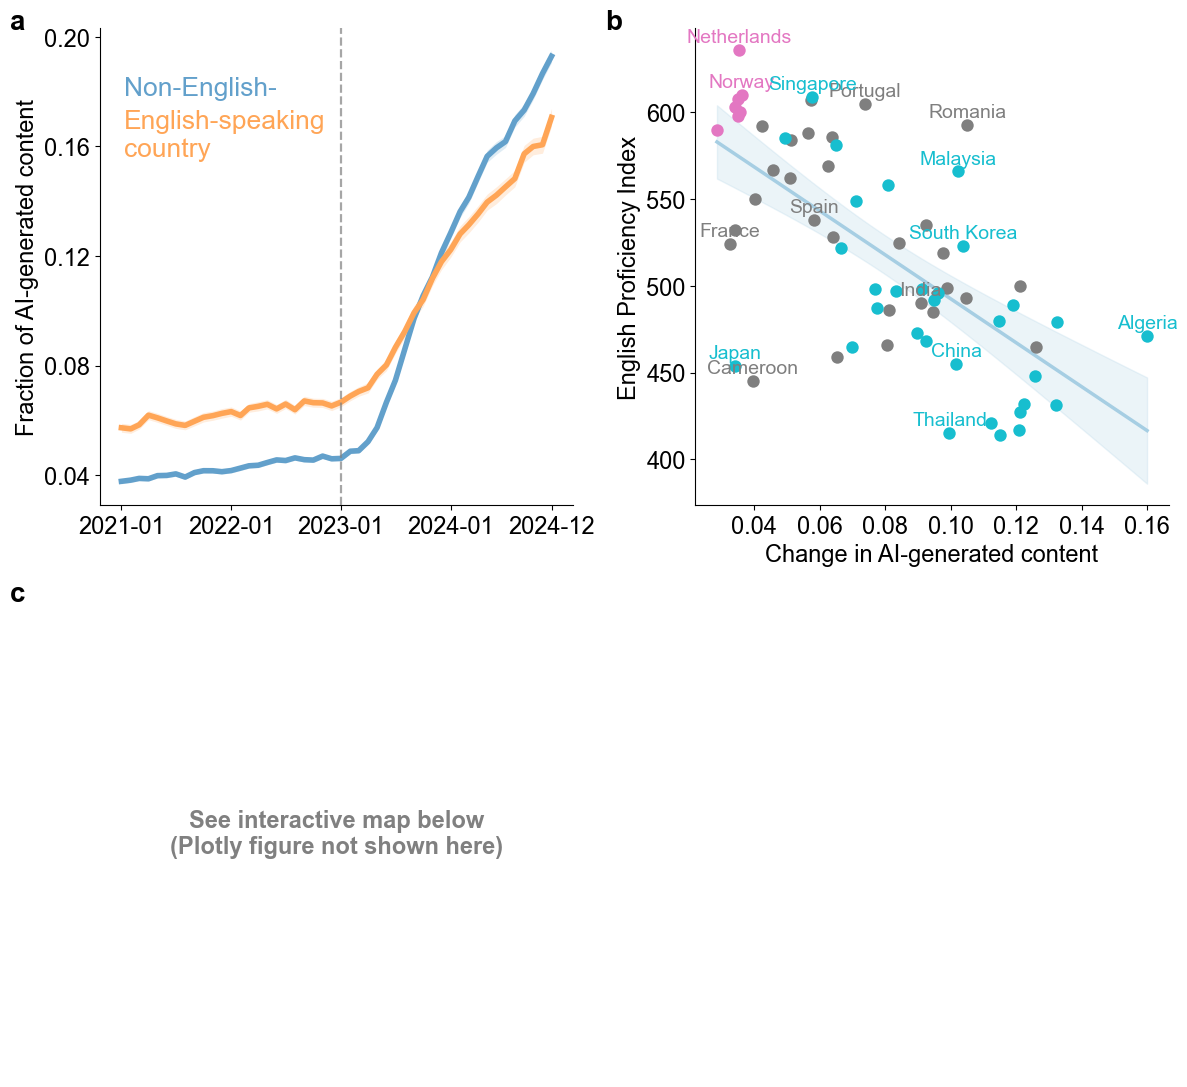

In [4]:
figure1, figure1_map = plot_author_figure("first")

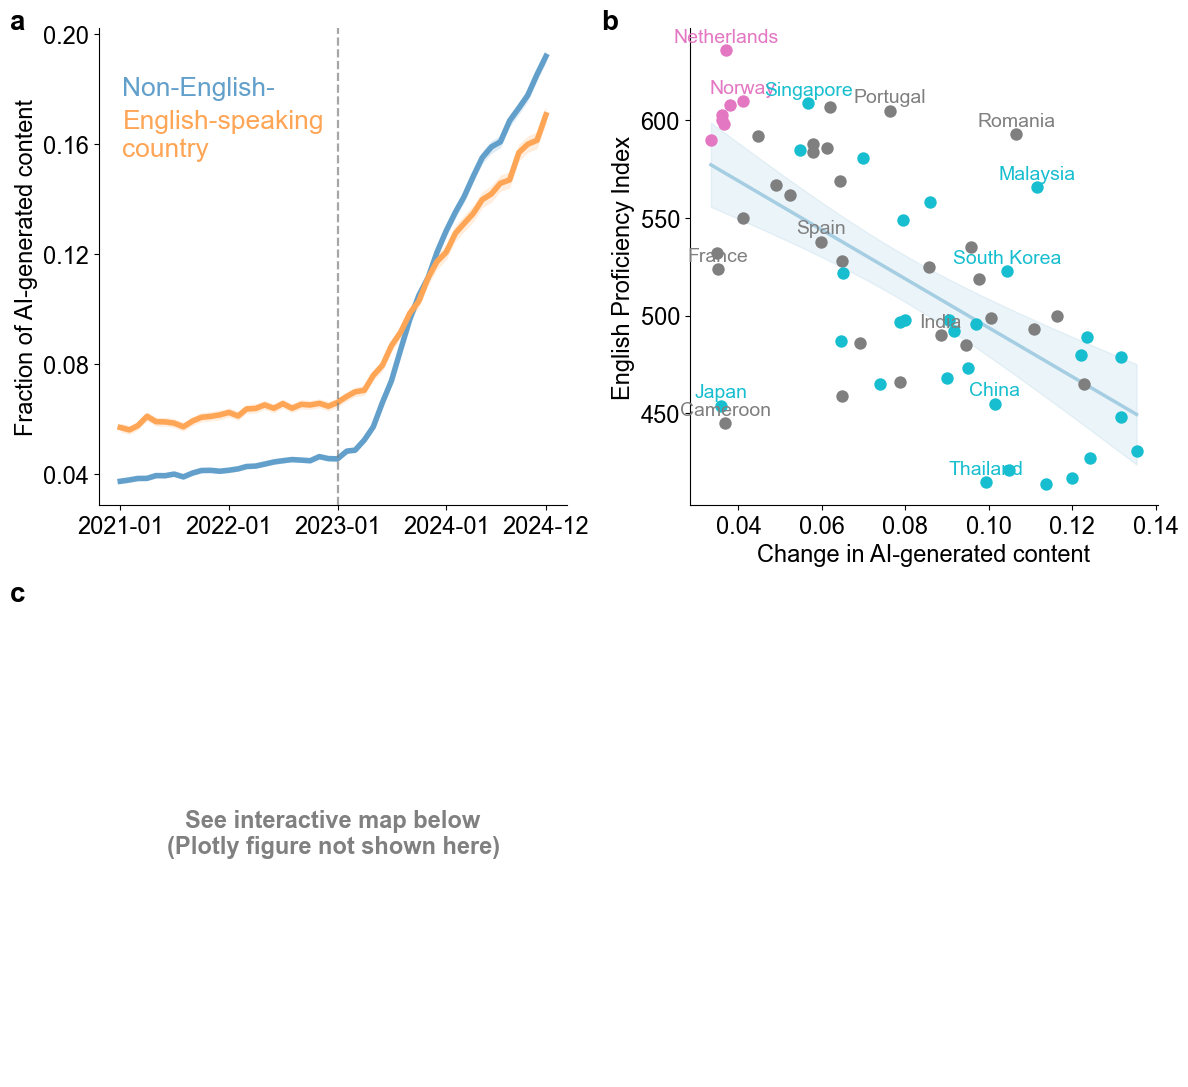

In [5]:
figure_s2, figure_s2_map = plot_author_figure("last")

# Figure 2 Author profile cross-group analysis

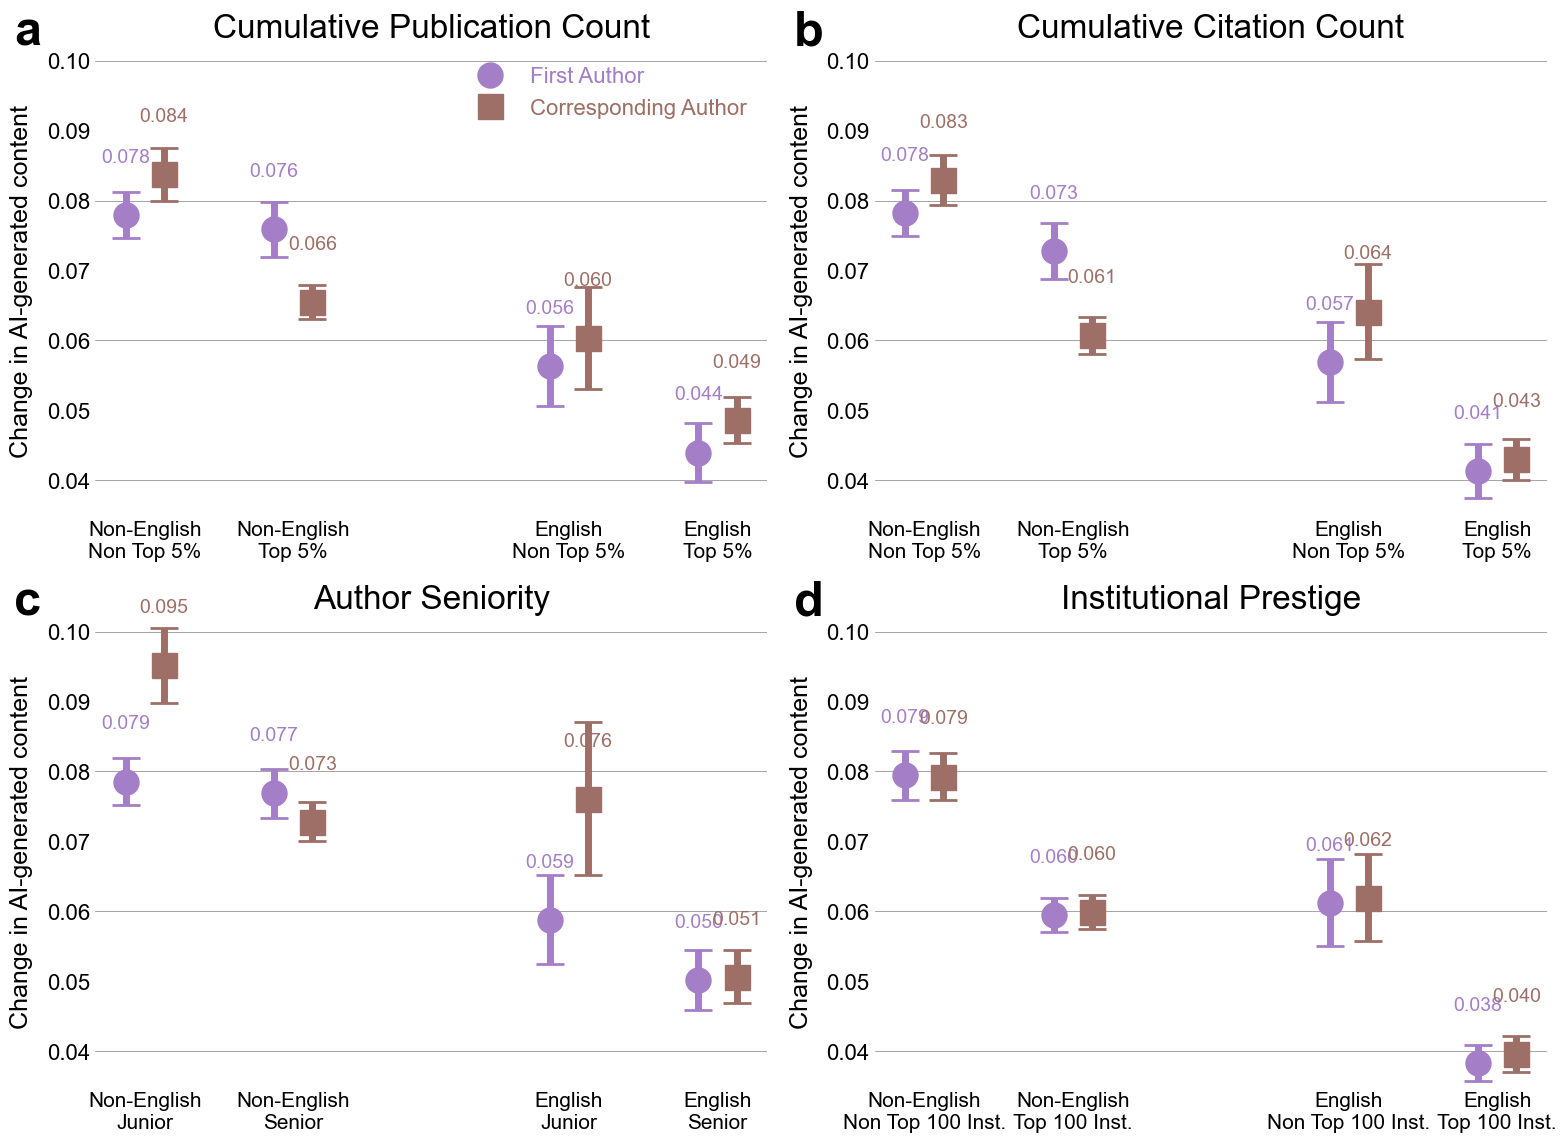

In [6]:
df = pd.read_csv('../../results/tables/group_ai_relative_change_affiliation_country_journal_subfield_fe_intro_discussion.csv')

df_filtered = df[
    ((df['indicator'] == 'age') & (df['level'] == 15)) |
    ((df['indicator'] == 'pub') & (df['level'] == 5)) |
    ((df['indicator'] == 'cit') & (df['level'] == 5)) |
    ((df['indicator'] == 'ins') & (df['level'] == 100))
]

FONT_FAMILY = 'Arial'
FONT_SIZE_GLOBAL = 15
XTICK_LABEL_SIZE = 16
XTICK_ROTATION = 0
XTICK_HA = 'center'
YTICK_LABEL_SIZE = 16
XTICK_TICKSIZE = 15
Y_AXIS_LABEL_SIZE = 18
Y_AXIS_LABELPAD = 10
PANEL_LABEL_SIZE = 35
PANEL_LABEL_WEIGHT = 'bold'
VALUE_TEXT_SIZE = 14
TITLE_SIZE = 24
LEGEND_SIZE = 16
LEGEND_MARKERSIZE = 18

plt.rcParams['font.family'] = FONT_FAMILY
plt.rcParams['font.size'] = FONT_SIZE_GLOBAL

nrows, ncols = 2, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 12))
axes = axes.flatten()
panel_labels = ['a', 'b', 'c', 'd']  # For subplot labeling

def get_group_label(english, top, indicator):
    if indicator in ['pub', 'cit']:
        top_label = 'Top 5%' if top == 1 else 'Non Top 5%'
    elif indicator == 'age':
        top_label = 'Senior' if top == 1 else 'Junior'
    elif indicator == 'ins':
        top_label = 'Top 100 Inst.' if top == 1 else 'Non Top 100 Inst.'
    english_label = 'English' if english == 1 else 'Non-English'
    return english_label, top_label

order_color = {'first': "#a47ec7", 'last': "#9d6f66"}  # Colors for roles
order_marker = {'first': 'o', 'last': 's'}             # Marker shapes
order_label = {'first': 'First Author', 'last': 'Corresponding Author'} # Legend labels

indicators = ['pub', 'cit', 'age', 'ins']  # Panel order (columns of interest)
indicator_map = {
    'pub': 'Cumulative Publication Count',
    'cit': 'Cumulative Citation Count',
    'age': 'Author Seniority',
    'ins': 'Institutional Prestige'
}
x_pos_custom = [0, 0.7, 2, 2.7]

for idx, indicator in enumerate(indicators):
    ax = axes[idx]
    sub = df_filtered[df_filtered['indicator'] == indicator].copy()
    sub[['english_label', 'top_label']] = sub.apply(
        lambda x: pd.Series(get_group_label(x['english'], x['top'], indicator)), axis=1)
    sub['group'] = list(zip(sub['english_label'], sub['top_label']))

    if indicator in ['pub', 'cit']:
        group_order = [
            ('Non-English', 'Non Top 5%'),
            ('Non-English', 'Top 5%'),
            ('English', 'Non Top 5%'),
            ('English', 'Top 5%')
        ]
    elif indicator == 'age':
        group_order = [
            ('Non-English', 'Junior'),
            ('Non-English', 'Senior'),
            ('English', 'Junior'),
            ('English', 'Senior')
        ]
    elif indicator == 'ins':
        group_order = [
            ('Non-English', 'Non Top 100 Inst.'),
            ('Non-English', 'Top 100 Inst.'),
            ('English', 'Non Top 100 Inst.'),
            ('English', 'Top 100 Inst.')
        ]
    else:
        group_order = sorted(list(sub['author_profile_group'].unique()))
    xticklabels = [f"{en}\n{top}" for en, top in group_order]
    x_pos = np.array(x_pos_custom)
    width = 0.18  # offset for grouped points

    for j, order in enumerate(['first', 'last']):
        data = sub[sub['order'] == order].copy()
        data = data.drop_duplicates(subset=['group'])  # Avoid duplicates
        data = data.set_index('group').reindex(group_order)  # Ensure all groups are present and ordered
        coef = data['ai_post_relative_change'].values      # Point estimates
        lower = data['lower'].values                      # Lower CI
        upper = data['upper'].values                      # Upper CI
        err = [coef - lower, upper - coef]                # Asymmetric error bars
        x = x_pos + (j-0.5)*width  # Offset for "first" vs "last"
        ax.errorbar(
            x, coef, yerr=err, fmt=order_marker[order],
            color=order_color[order], capsize=10, linewidth=5, capthick=2, markersize=LEGEND_MARKERSIZE
        )
        for i, c in enumerate(coef):
            if not np.isnan(c):
                ax.text(
                    x[i], c+0.007, f'{c:.3f}', va='bottom',
                    ha='center', fontsize=VALUE_TEXT_SIZE, color=order_color[order]
                )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(xticklabels, fontsize=XTICK_LABEL_SIZE, rotation=XTICK_ROTATION, ha=XTICK_HA)
    ax.set_ylabel('Change in AI-generated content', fontsize=Y_AXIS_LABEL_SIZE, labelpad=Y_AXIS_LABELPAD)
    ax.text(
        -0.12, 1.08, panel_labels[idx], transform=ax.transAxes,
        fontsize=PANEL_LABEL_SIZE, fontweight=PANEL_LABEL_WEIGHT, va='top', ha='left'
    )

    ax.set_ylim(0.035, 0.102)
    ax.set_yticks([0.04,0.05,0.06,0.07, 0.08, 0.09,0.10])
    for y in np.arange(0, 0.11, 0.02):
        ax.axhline(y, color='gray', linestyle='-', linewidth=0.5, zorder=0)
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis='x', labelsize=XTICK_TICKSIZE, width=0, length=0)
    ax.tick_params(axis='y', labelsize=YTICK_LABEL_SIZE, width=0, length=0)

for idx, indicator in enumerate(indicators):
    axes[idx].set_title(indicator_map[indicator], fontsize=TITLE_SIZE, pad=7, loc='center')

if len(axes) > len(indicators):
    for k in range(len(indicators), len(axes)):
        fig.delaxes(axes[k])

legend_handles = [
    Line2D([0], [0], marker=order_marker['first'], color='w', markerfacecolor=order_color['first'],
           markeredgecolor=order_color['first'], markersize=LEGEND_MARKERSIZE, linewidth=0, label=order_label['first']),
    Line2D([0], [0], marker=order_marker['last'], color='w', markerfacecolor=order_color['last'],
           markeredgecolor=order_color['last'], markersize=LEGEND_MARKERSIZE, linewidth=0, label=order_label['last']),
]

legend_labels = [order_label['first'], order_label['last']]
legend_text_colors = [order_color['first'], order_color['last']]

leg = axes[0].legend(
    handles=legend_handles,
    labels=legend_labels,
    fontsize=LEGEND_SIZE,
    loc='upper right',
    frameon=False,
    handlelength=2,
    handler_map=None
)

for text, color in zip(leg.get_texts(), legend_text_colors):
    text.set_color(color)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Figure 3 AI-author analysis and productivity Change Analysis

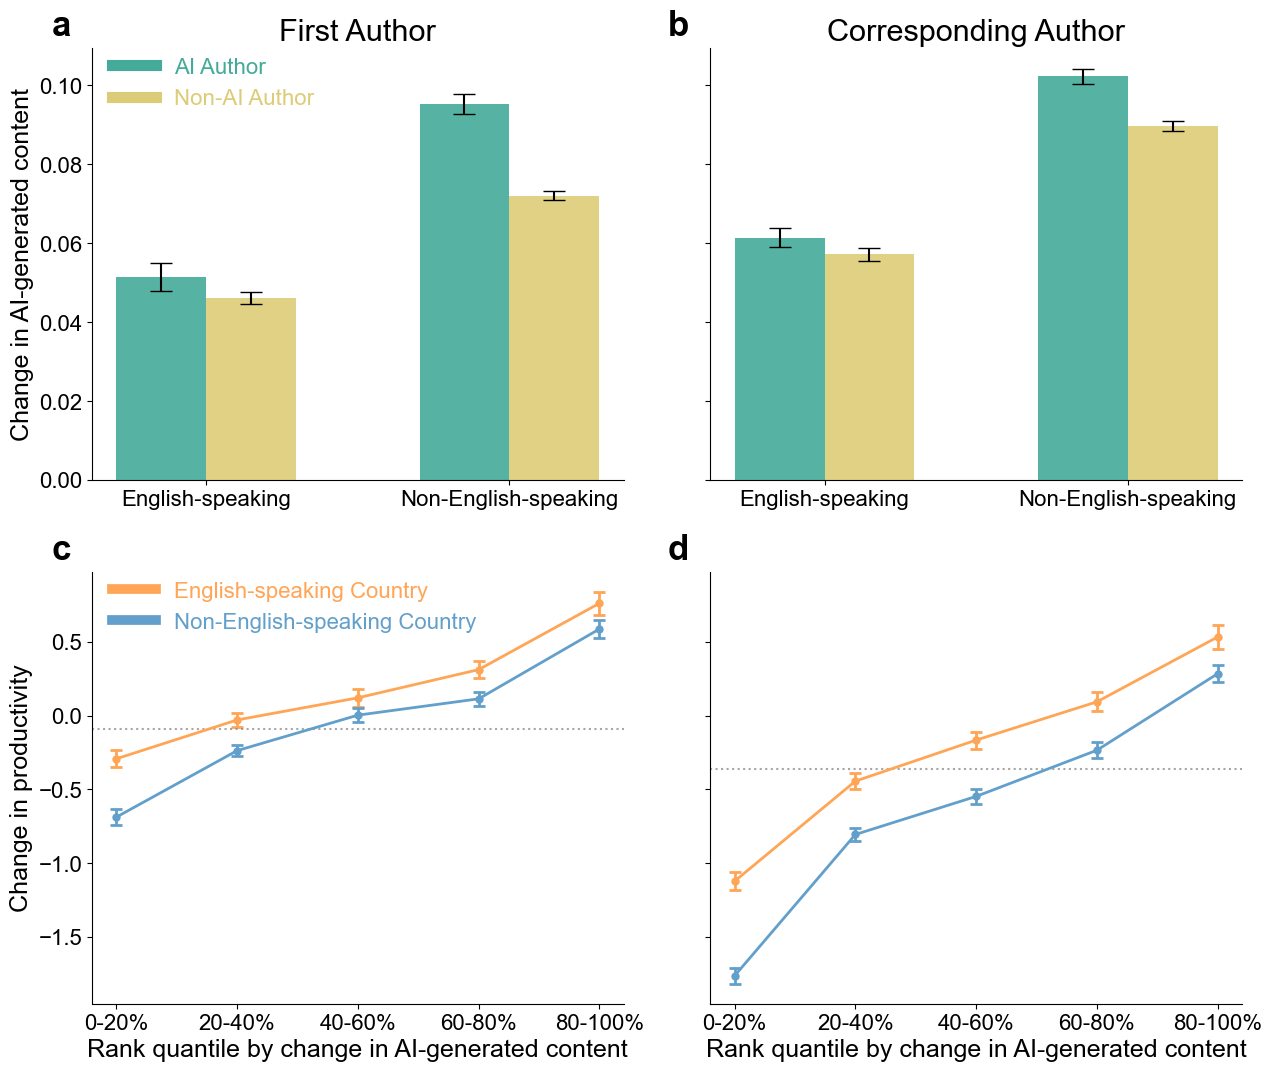

In [7]:
FONT_FAMILY = 'Arial'
FONT_SIZE_BASE = 16
FONT_SIZE_TICKLABEL = 16
FONT_SIZE_XLABEL = 18
FONT_SIZE_YLABEL = 18
FONT_SIZE_TITLE = 22
FONT_SIZE_PANEL = 25
FONT_SIZE_LEGEND = 16

LINE_WIDTH = 2
MARKER_SIZE = 4 
MARKER_EDGE_WIDTH = 2
CAP_SIZE = 4   
MARKER_STYLE = 'o'  

x_labels = ['English-speaking', 'Non-English-speaking']
ai_labels = ['AI Author', 'Non-AI Author']
ai_values = [1, 0]
bar_width = 0.35
group_gap = 0.18
quantile_labels = [f'{i*20}-{(i+1)*20}%' for i in range(5)]

plt.rcParams['font.family'] = FONT_FAMILY
plt.rcParams['font.size'] = FONT_SIZE_BASE

df_fig3ab = pd.read_csv("../../results/figure_data/data_figure3ab.csv")
df_fig4cd = pd.read_csv("../../results/figure_data/data_figure4cd.csv")
import re
with open("../../results/figure_data/figure4cd_zeroline_info.txt") as f:
    zerolines = f.read().strip().split("\n")
    match_first = re.findall(r"first_author_zero_quantile: (\d+), mean: ([\d\.\-eE]+)", zerolines[0])
    match_last = re.findall(r"corresponding_author_zero_quantile: (\d+), mean: ([\d\.\-eE]+)", zerolines[1])
    zero_quantile_first, mean_zero_first = int(match_first[0][0]), float(match_first[0][1])
    zero_quantile_last, mean_zero_last = int(match_last[0][0]), float(match_last[0][1])

colors_bar = {'AI Author':"#44AA99", 'Non-AI Author':"#DDCC77"}
colors_line = {'English-speaking':"#ffa556", 'Non-English-speaking':"#62a0cb"}

fig, axes = plt.subplots(2, 2, figsize=(13, 11), sharey='row')
panel_labels = ['a', 'b', 'c', 'd']

for idx, (ax, role, title) in enumerate(zip(
    axes[0],
    ['First Author', 'Corresponding Author'],
    ['First Author', 'Corresponding Author']
)):
    rows = df_fig3ab[df_fig3ab['role']==role]
    for i, country in enumerate(x_labels):
        for j, ai in enumerate(ai_labels):
            bar_idx = 2*i + j
            row = rows[(rows['country']==country) & (rows['ai_author']==ai)].iloc[0]
            color = colors_bar[ai]
            label = ai if (i == 0 and j == 0) or (i == 0 and j == 1) else None
            ax.bar(
                np.array([0, 0 + bar_width, 1 + group_gap, 1 + group_gap + bar_width])[bar_idx],
                row['mean_ai_use_change'], width=bar_width, yerr=row['ci'], capsize=8,
                color=color, alpha=0.9, label=label
            )
    ax.set_xticks([0 + bar_width/2, 1 + group_gap + bar_width/2])
    ax.set_xticklabels(x_labels, fontname=FONT_FAMILY, fontsize=FONT_SIZE_TICKLABEL)
    ax.set_title(title, fontname=FONT_FAMILY, fontsize=FONT_SIZE_TITLE)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    if idx == 0:
        ax.set_ylabel('Change in AI-generated content', fontname=FONT_FAMILY, fontsize=FONT_SIZE_YLABEL)
        handles = [
            plt.Line2D([0], [0], color=colors_bar['AI Author'], lw=8, label='AI Author'),
            plt.Line2D([0], [0], color=colors_bar['Non-AI Author'], lw=8, label='Non-AI Author')
        ]
        leg = ax.legend(handles=handles, loc='upper left', frameon=False, bbox_to_anchor=(0.02, 1), borderaxespad=0, fontsize=FONT_SIZE_LEGEND)
        legend_texts = leg.get_texts()
        for txt, c in zip(legend_texts, [colors_bar['AI Author'], colors_bar['Non-AI Author']]):
            txt.set_color(c)
    else:
        ax.legend().remove()
    ax.text(-0.04, 1.09, panel_labels[idx], transform=ax.transAxes, fontsize=FONT_SIZE_PANEL, fontweight='bold',
            va='top', ha='right')

for idx, (ax, role, mean_zero) in enumerate(zip(
    axes[1],
    ['First Author', 'Corresponding Author'],
    [mean_zero_first, mean_zero_last]
)):
    subdf = df_fig4cd[df_fig4cd['role']==role]
    for country in x_labels:
        country_sub = subdf[subdf['country']==country].sort_values("quantile")
        means = country_sub['mean_productivity_change'].values
        cis = country_sub['ci'].values
        quantile_idxs = country_sub['quantile'].values
        color = colors_line[country]
        label = country
        ax.errorbar(
            quantile_idxs, means, yerr=cis, fmt=f'{MARKER_STYLE}-', capsize=CAP_SIZE,
            color=color, ecolor=color, label=label,
            linewidth=LINE_WIDTH, markersize=MARKER_SIZE, markeredgewidth=MARKER_EDGE_WIDTH,
        )
    ax.axhline(mean_zero, color='grey', linestyle=':', alpha=0.7)
    ax.set_xlabel('Rank quantile by change in AI-generated content', fontname=FONT_FAMILY, fontsize=FONT_SIZE_XLABEL)
    ax.set_xticks(quantile_idxs)
    ax.set_xticklabels([quantile_labels[i] for i in quantile_idxs], fontname=FONT_FAMILY, fontsize=FONT_SIZE_TICKLABEL)
    if idx == 0:
        ax.set_ylabel('Change in productivity', fontname=FONT_FAMILY, fontsize=FONT_SIZE_YLABEL)
        handles = [
            plt.Line2D([0], [0], color=colors_line['English-speaking'], lw=7, label='English-speaking Country'),
            plt.Line2D([0], [0], color=colors_line['Non-English-speaking'], lw=7, label='Non-English-speaking Country')
        ]
        leg = ax.legend(handles=handles, loc='upper left', frameon=False, bbox_to_anchor=(0.02, 1), borderaxespad=0, fontsize=FONT_SIZE_LEGEND)
        legend_texts = leg.get_texts()
        for txt, c in zip(legend_texts, [colors_line['English-speaking'], colors_line['Non-English-speaking']]):
            txt.set_color(c)
    else:
        ax.legend().remove()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.text(-0.04, 1.09, panel_labels[idx+2], transform=ax.transAxes, fontsize=FONT_SIZE_PANEL, fontweight='bold',
            va='top', ha='right')

plt.subplots_adjust(left=0.08, right=0.98, top=0.94, bottom=0.08, wspace=0.18, hspace=0.22)
plt.tight_layout()
plt.show()

# Figure S1 Parallel trends assumption

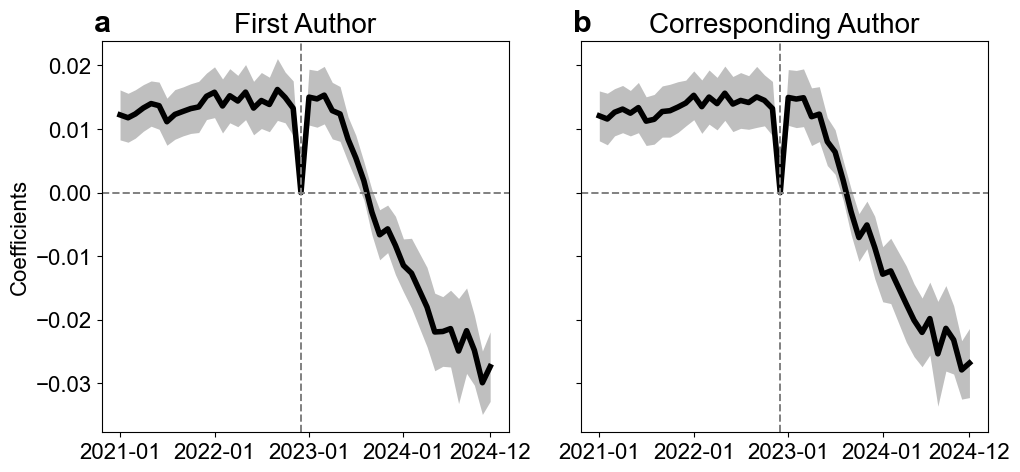

In [8]:
FONT_FAMILY = 'arial'
FONT_SIZE = 16
TITLE_SIZE = 20
LABEL_SIZE = 16
TICK_SIZE = 16
PANEL_LABEL_SIZE = 22
PANEL_LABEL_WEIGHT = 'bold'

MAIN_COLOR = 'black'
ALPHA_FILL = 0.25
LINEWIDTH_MAIN = 4
LINEWIDTH_AUX = 1.4

plt.rcParams['font.family'] = FONT_FAMILY
plt.rcParams['font.size'] = FONT_SIZE

df = pd.read_csv('../../results/figure_data/data_figure_s1.csv')

df['date'] = df['year_month'].astype(str)

row_to_insert = {
    'year_month': '2022-12',
    'first_coef': 0,
    'first_coef_low': 0,
    'first_coef_high': 0,
    'last_coef': 0,
    'last_coef_low': 0,
    'last_coef_high': 0,
    'date': '2022-12'
}
insert_idx = df[df['date'] == '2022-01'].index.max() + 1
df = pd.concat([
    df.iloc[:insert_idx],
    pd.DataFrame([row_to_insert]),
    df.iloc[insert_idx:]
], ignore_index=True)

df['date_dt'] = pd.to_datetime(df['date'], format='%Y-%m')
df = df.sort_values('date_dt').reset_index(drop=True)

target_labels = ['2021-01', '2022-01', '2023-01', '2024-01', '2024-12']

fig, axes = plt.subplots(1, 2, figsize=(10.5, 5), sharey=True)
x = df['date_dt']

# Panel a: First Author
axes[0].plot(x, df['first_coef'], color=MAIN_COLOR, linewidth=LINEWIDTH_MAIN)
axes[0].fill_between(
    x, df['first_coef_low'], df['first_coef_high'],
    color=MAIN_COLOR, alpha=ALPHA_FILL, linewidth=0
)
axes[0].axhline(0, color='grey', linestyle='--', linewidth=LINEWIDTH_AUX)
x_2022_12 = pd.to_datetime('2022-12', format='%Y-%m')
axes[0].axvline(x_2022_12, color='grey', linestyle='--', linewidth=LINEWIDTH_AUX)
axes[0].set_title('First Author', fontname=FONT_FAMILY, fontsize=TITLE_SIZE)
axes[0].set_ylabel('Coefficients', fontname=FONT_FAMILY, fontsize=LABEL_SIZE)
axes[0].tick_params(axis='both', which='major', labelsize=TICK_SIZE)
axes[0].set_xlabel('')
axes[0].text(-0.02, 1.08, 'a', transform=axes[0].transAxes, 
             fontsize=PANEL_LABEL_SIZE, fontweight=PANEL_LABEL_WEIGHT, 
             va='top', ha='left')

# Panel b: Corresponding (Last) Author
axes[1].plot(x, df['last_coef'], color=MAIN_COLOR, linewidth=LINEWIDTH_MAIN)
axes[1].fill_between(
    x, df['last_coef_low'], df['last_coef_high'],
    color=MAIN_COLOR, alpha=ALPHA_FILL, linewidth=0
)
axes[1].axhline(0, color='grey', linestyle='--', linewidth=LINEWIDTH_AUX)
axes[1].axvline(x_2022_12, color='grey', linestyle='--', linewidth=LINEWIDTH_AUX)
axes[1].set_title('Corresponding Author', fontname=FONT_FAMILY, fontsize=TITLE_SIZE)
axes[1].tick_params(axis='both', which='major', labelsize=TICK_SIZE)
axes[1].set_xlabel('')
axes[1].text(-0.02, 1.08, 'b', transform=axes[1].transAxes, 
             fontsize=PANEL_LABEL_SIZE, fontweight=PANEL_LABEL_WEIGHT, 
             va='top', ha='left')

for ax in axes:
    tick_labels = df['date'].tolist()
    ticks_to_label = [i for i, v in enumerate(tick_labels) if v in target_labels]
    tick_values = df.loc[ticks_to_label, 'date_dt']
    ax.set_xticks(tick_values)
    ax.set_xticklabels([tick_labels[i] for i in ticks_to_label],
                       fontname=FONT_FAMILY, fontsize=TICK_SIZE)

plt.tight_layout()
plt.show()


# Figure S3-S7 Robustness check and recent output velocity analysis

pub


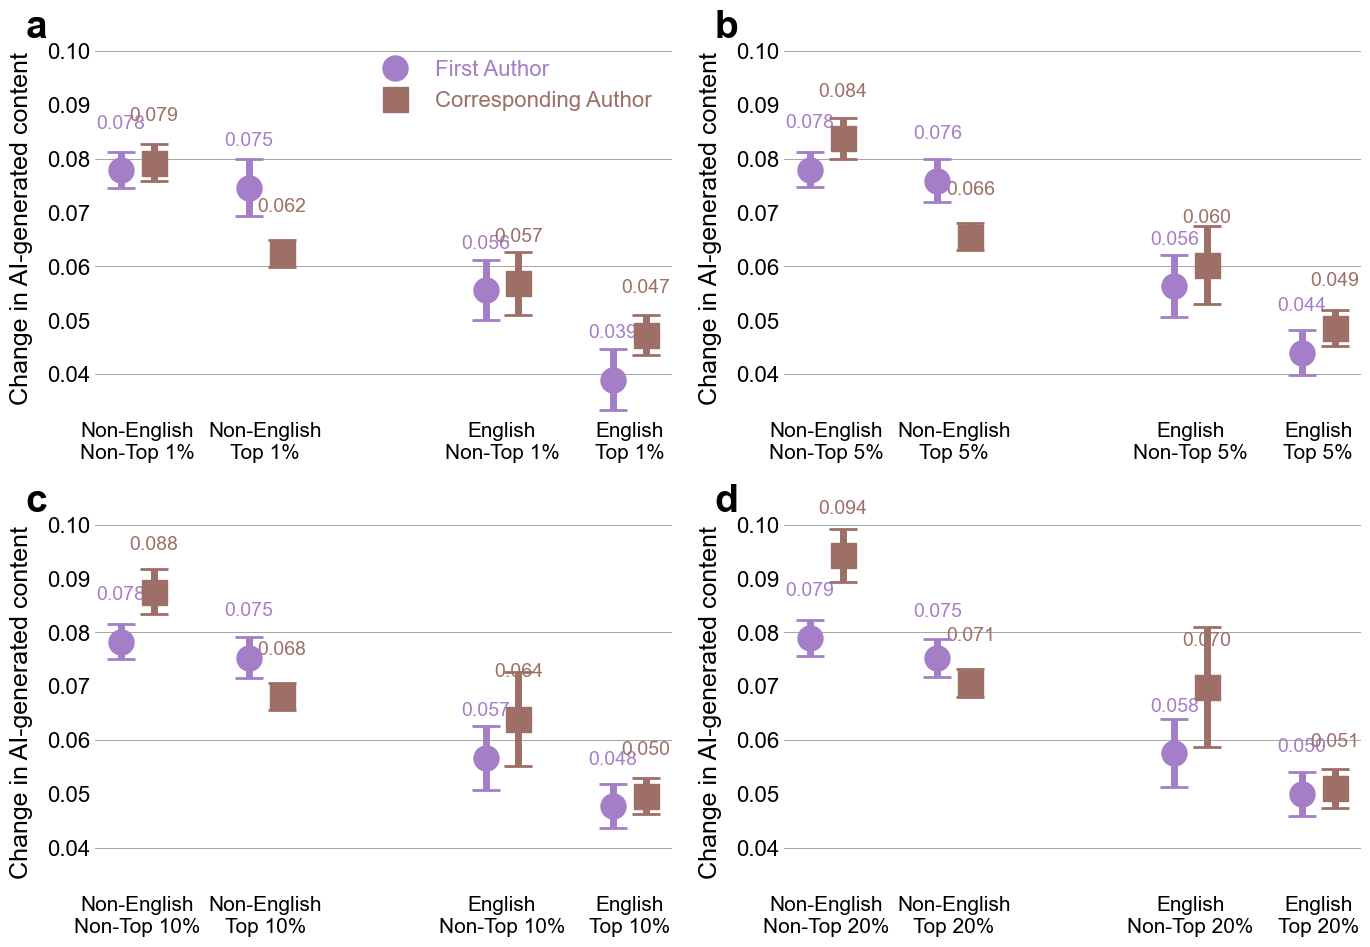

cit


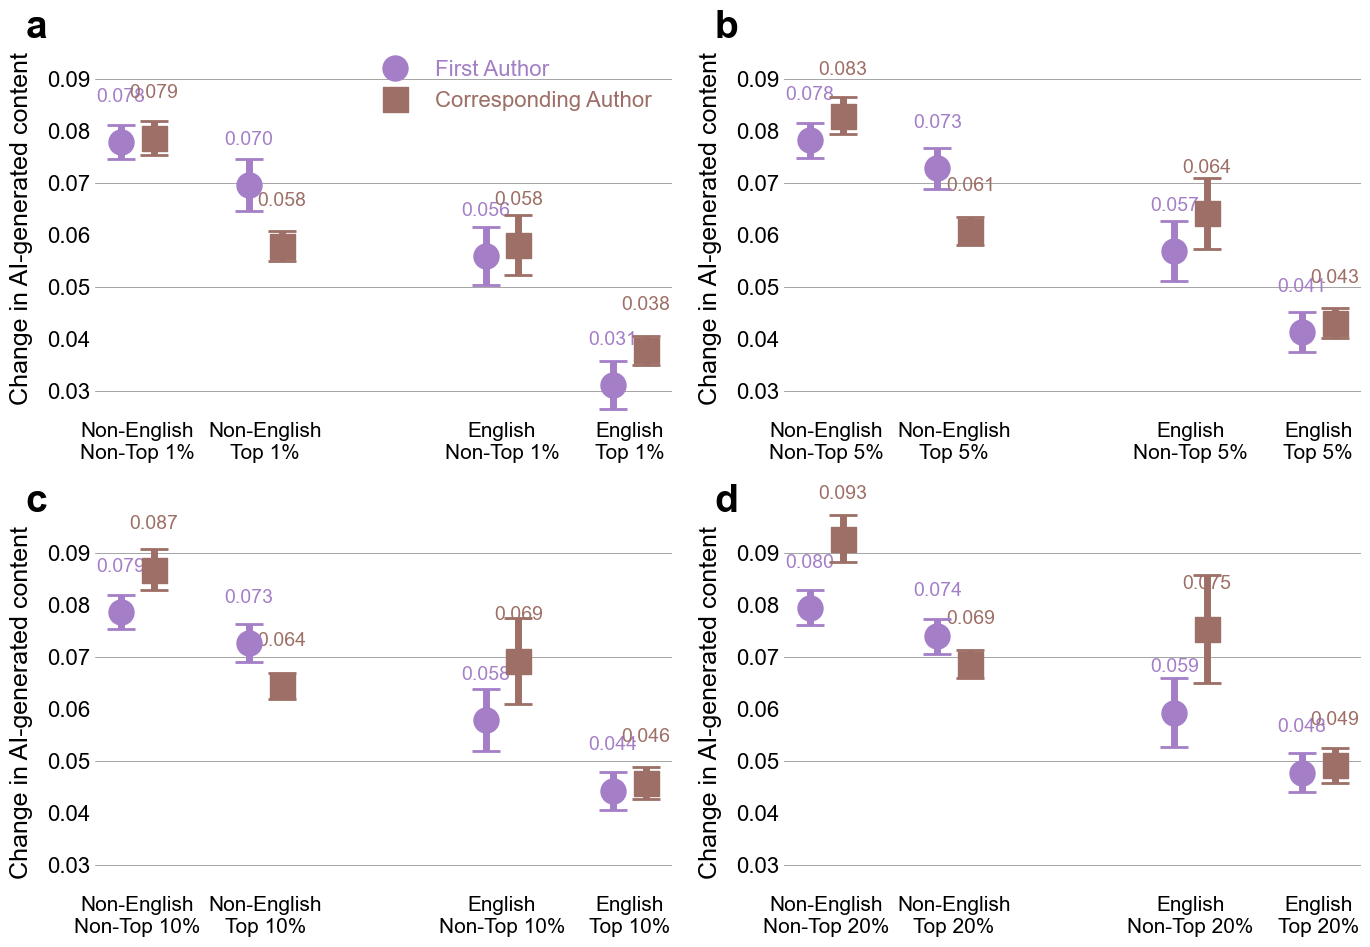

age


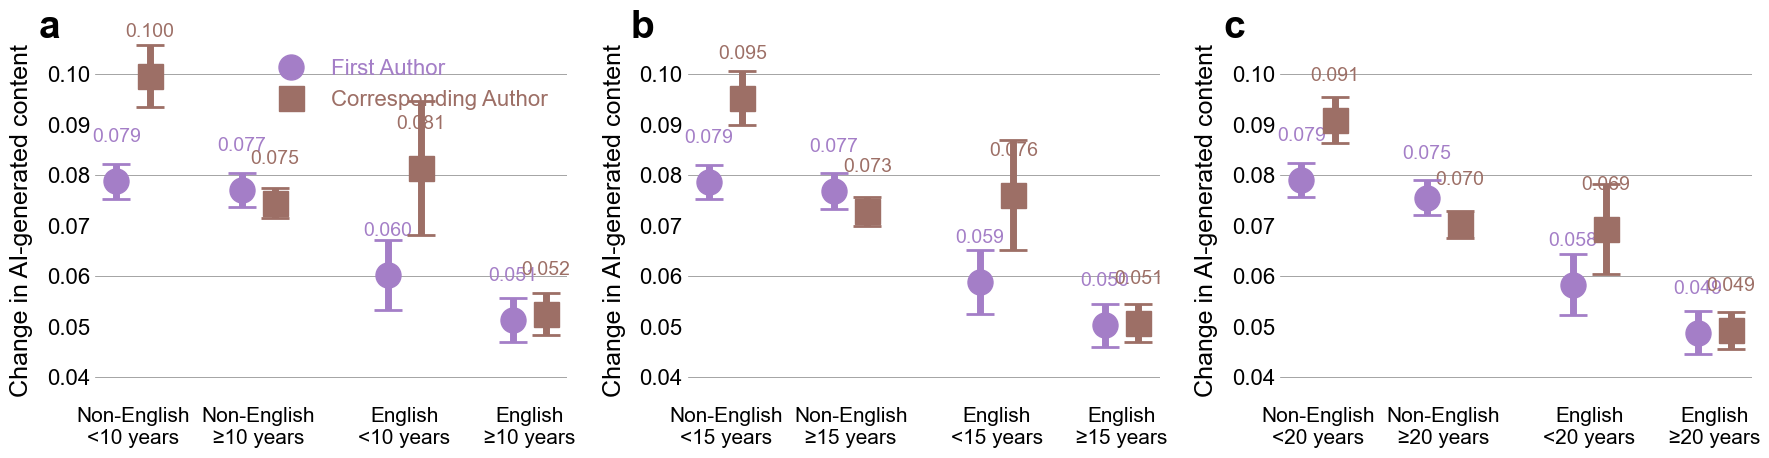

ins


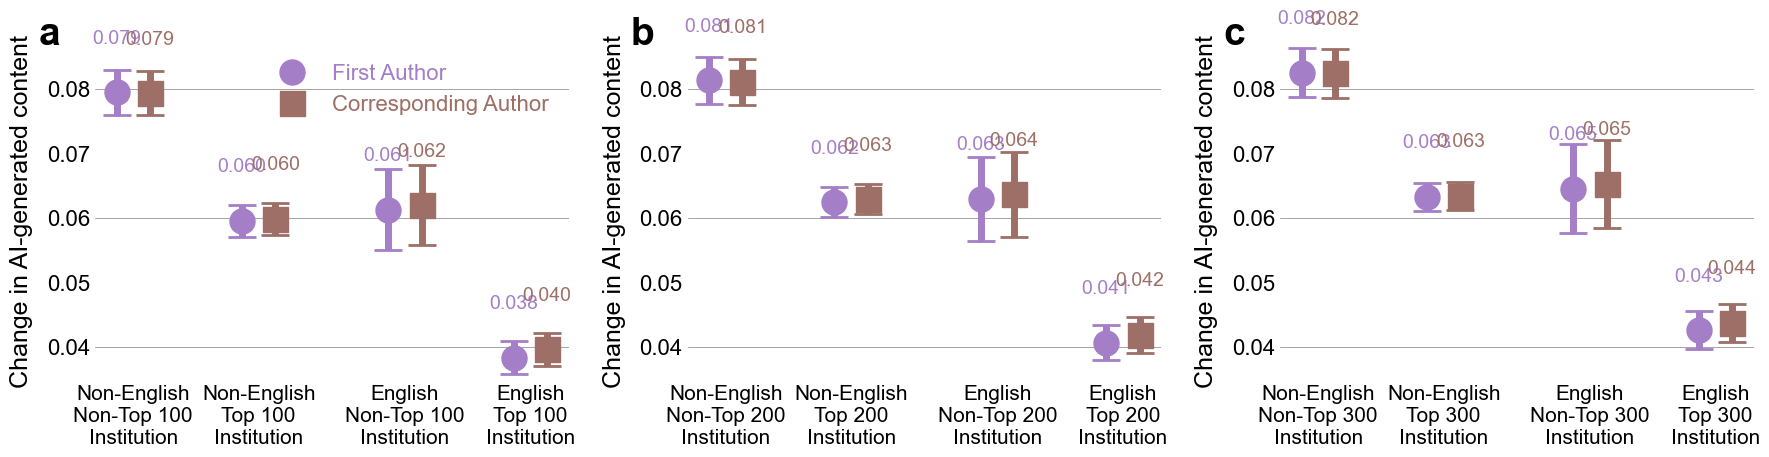

pub_recent2year


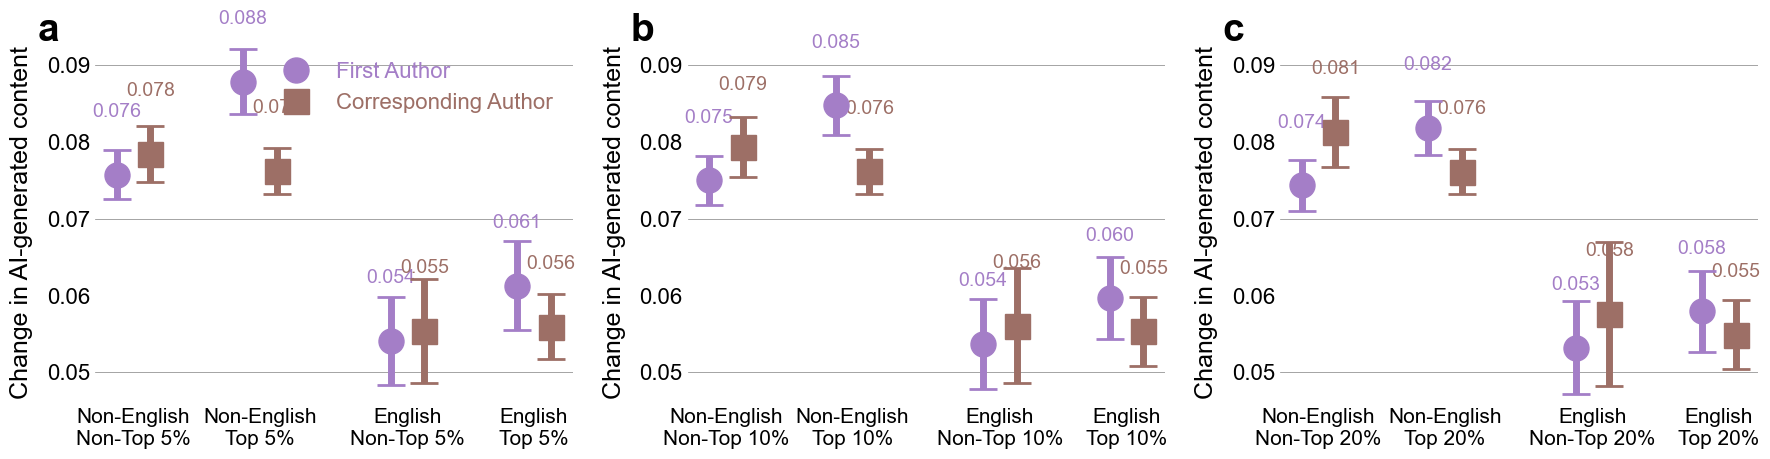

In [9]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 15

level_label_map = {
    'pub': {1: "Top 1%", 5: "Top 5%", 10: "Top 10%", 20: "Top 20%"},
    'cit': {1: "Top 1%", 5: "Top 5%", 10: "Top 10%", 20: "Top 20%"},
    'ins': {100: "Top 100 Inst.", 200: "Top 200 Inst.", 300: "Top 300 Inst."},
    'age': {10: "≥10 yrs Seniority", 15: "≥15 yrs Seniority", 20: "≥20 yrs Seniority"},
    'pub_recent2year': {5: "Top 5%", 10: "Top 10%", 20: "Top 20%"}
}

def get_group_label_level(english, top, indicator, level):
    """
    Generate group label tuples based on language, group, indicator, and level.
    """
    english_label = 'English' if english == 1 else 'Non-English'
    if indicator in ['pub', 'cit','pub_recent2year']:
        top_label = f"Top {level}%" if top == 1 else f"Non-Top {level}%"
    elif indicator == 'ins':
        top_label = f"Top {level} Inst." if top == 1 else f"Non-Top {level} Inst."
    elif indicator == 'age':
        top_label = f"≥{level} yrs Seniority" if top == 1 else f"<{level} yrs Seniority"
    else:
        top_label = f"Top={top}"
    return english_label, top_label

order_color = {'first': "#a47ec7", 'last': "#9d6f66"}
order_marker = {'first': 'o', 'last': 's'}
order_label = {'first': 'First Author', 'last': 'Corresponding Author'}

df = pd.read_csv('../../results/tables/group_ai_relative_change_affiliation_country_journal_subfield_fe_intro_discussion.csv')

indicator_for_plot = [
    ('pub', [1, 5, 10, 20]),
    ('cit', [1, 5, 10, 20]),
    ('age', [10, 15, 20]),
    ('ins', [100, 200, 300]),
    ('pub_recent2year', [5, 10, 20])]

from string import ascii_lowercase

first_corresponding_width_gap = [0.18, 0.18, 0.32, 0.32, 0.32]

for idx, (indicator, level_list) in enumerate(indicator_for_plot):
    print(indicator)
    panel_labels = list(ascii_lowercase)[:len(level_list)]
    panel_label_counter = 0

    if indicator in ['pub', 'cit']:
        nrows, ncols = 2, 2
        figsize = (14, 10)
        x_pos_custom = [0, 0.7, 2, 2.7]
    else:
        nrows, ncols = 1, 3
        figsize = (18, 5)
        x_pos_custom = [0, 1.2, 2.6, 3.8]
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=False)
    axes = np.array(axes).reshape(-1)

    for j, level in enumerate(level_list):
        ax = axes[j]
        sub = df[(df['indicator'] == indicator) & (df['level'] == level)].copy()
        sub[['english_label', 'top_label']] = sub.apply(
            lambda x: pd.Series(get_group_label_level(x['english'], x['top'], indicator, level)), axis=1)
        sub['top'] = list(zip(sub['english_label'], sub['top_label']))

        if indicator in ['pub', 'cit','pub_recent2year']:
            group_order = [
                ('Non-English', f"Non-Top {level}%"),
                ('Non-English', f"Top {level}%"),
                ('English', f"Non-Top {level}%"),
                ('English', f"Top {level}%")
            ]
            xticklabels = [
                f"Non-English\nNon-Top {level}%",
                f"Non-English\nTop {level}%",
                f"English\nNon-Top {level}%",
                f"English\nTop {level}%"
            ]
        elif indicator == 'age':
            group_order = [
                ('Non-English', f"<{level} yrs Seniority"),
                ('Non-English', f"≥{level} yrs Seniority"),
                ('English', f"<{level} yrs Seniority"),
                ('English', f"≥{level} yrs Seniority")
            ]
            xticklabels = [
                f"Non-English\n<{level} years",
                f"Non-English\n≥{level} years",
                f"English\n<{level} years",
                f"English\n≥{level} years"
            ]
        else:
            group_order = [
                ('Non-English', f"Non-Top {level} Inst."),
                ('Non-English', f"Top {level} Inst."),
                ('English', f"Non-Top {level} Inst."),
                ('English', f"Top {level} Inst.")
            ]
            xticklabels = [
                f"Non-English\nNon-Top {level}\nInstitution",
                f"Non-English\nTop {level}\nInstitution",
                f"English\nNon-Top {level}\nInstitution",
                f"English\nTop {level}\nInstitution"
            ]
        x_pos = np.array(x_pos_custom)
        width = first_corresponding_width_gap[idx]

        for k, order in enumerate(['first', 'last']):
            data = sub[sub['order'] == order]
            data = data.set_index('top').reindex(group_order)
            coef = data['ai_post_relative_change'].values
            lower = data['lower'].values
            upper = data['upper'].values
            err = [coef - lower, upper - coef]
            x = x_pos + (k - 0.5) * width
            ax.errorbar(
                x, coef, yerr=err, fmt=order_marker[order],
                color=order_color[order], capsize=10, linewidth=5, capthick=2, markersize=18, zorder=5,
            )
            for i, c in enumerate(coef):
                if pd.isnull(c):
                    continue
                ax.text(
                    x[i], c + 0.007, f'{c:.3f}', va='bottom',
                    ha='center', fontsize=14, color=order_color[order]
                )

        ax.set_xticks(x_pos)
        ax.set_xticklabels(xticklabels, fontsize=16, rotation=0, ha='center')
        ax.set_ylabel('Change in AI-generated content', fontsize=18, labelpad=10)

        if idx ==0:
            ax.set_ylim(0.032, 0.102)
            for y in np.arange(0, 0.11, 0.02):
                ax.axhline(y, color='gray', linestyle='-', linewidth=0.5, zorder=0)
            plt.yticks([0.04, 0.05, 0.06, 0.07,0.08,0.09,0.10])
        if idx ==1:
            ax.set_ylim(0.025, 0.0975)
            for y in np.arange(0.01, 0.11, 0.02):
                ax.axhline(y, color='gray', linestyle='-', linewidth=0.5, zorder=0)
            plt.yticks([0.03,0.04, 0.05, 0.06, 0.07,0.08,0.09])
        if idx == 2:
            ax.set_ylim(0.035, 0.107)
            for y in np.arange(0, 0.11, 0.02):
                ax.axhline(y, color='gray', linestyle='-', linewidth=0.5, zorder=0)
        if idx == 3:
            ax.set_ylim(0.035, 0.087)
            for y in np.arange(0, 0.11, 0.02):
                ax.axhline(y, color='gray', linestyle='-', linewidth=0.5, zorder=0)
        if idx == 4:
            ax.set_ylim(0.046, 0.093)
            for y in np.arange(0.01, 0.11, 0.02):
                ax.axhline(y, color='gray', linestyle='-', linewidth=0.5, zorder=0)

        for spine in ['top', 'right', 'left', 'bottom']:
            ax.spines[spine].set_visible(False)
        ax.tick_params(axis='x', labelsize=15, width=0, length=0)
        ax.tick_params(axis='y', labelsize=16, width=0, length=0)

        ax.text(
            -0.12, 1.08, panel_labels[panel_label_counter], transform=ax.transAxes,
            fontsize=28, fontweight='bold', va='top', ha='left'
        )
        panel_label_counter += 1

    for k in range(len(level_list), nrows * ncols):
        fig.delaxes(axes[k])

    legend_handles = [
        Line2D([0], [0], marker=order_marker['first'], color='w', markerfacecolor=order_color['first'],
               markeredgecolor=order_color['first'], markersize=18, linewidth=0, label=order_label['first']),
        Line2D([0], [0], marker=order_marker['last'], color='w', markerfacecolor=order_color['last'],
               markeredgecolor=order_color['last'], markersize=18, linewidth=0, label=order_label['last']),
    ]
    legend_labels = [order_label['first'], order_label['last']]
    legend_text_colors = [order_color['first'], order_color['last']]

    leg = axes[0].legend(
        handles=legend_handles,
        labels=legend_labels,
        fontsize=16,
        loc='upper right',
        frameon=False,
        handlelength=2,
        handler_map=None
    )
    for text, color in zip(leg.get_texts(), legend_text_colors):
        text.set_color(color)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# Figure S8 Robustness check for text in Methods and Results

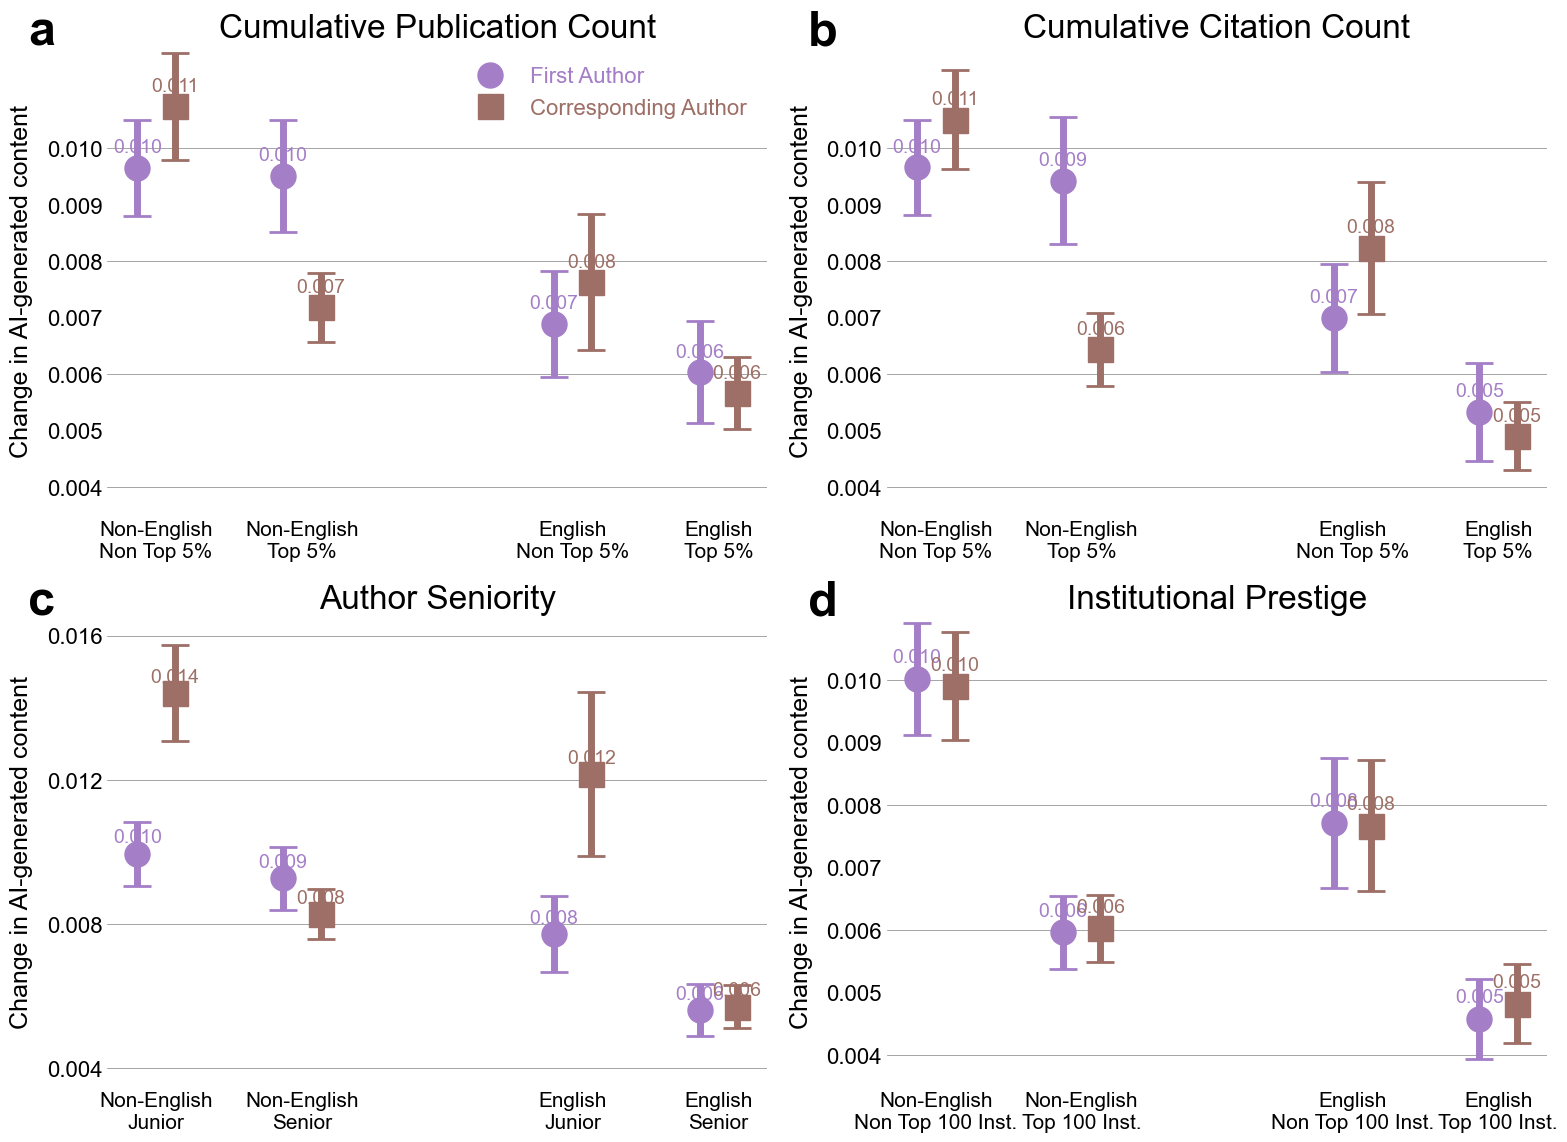

In [10]:
df = pd.read_csv('../../results/tables/group_ai_relative_change_affiliation_country_journal_subfield_fe_method_results.csv')

df_filtered = df[
    ((df['indicator'] == 'age') & (df['level'] == 15)) |
    ((df['indicator'] == 'pub') & (df['level'] == 5)) |
    ((df['indicator'] == 'cit') & (df['level'] == 5)) |
    ((df['indicator'] == 'ins') & (df['level'] == 100))
]

FONT_FAMILY = 'Arial'
FONT_SIZE_GLOBAL = 15
XTICK_LABEL_SIZE = 16
XTICK_ROTATION = 0
XTICK_HA = 'center'
YTICK_LABEL_SIZE = 16
XTICK_TICKSIZE = 15
Y_AXIS_LABEL_SIZE = 18
Y_AXIS_LABELPAD = 10
PANEL_LABEL_SIZE = 35
PANEL_LABEL_WEIGHT = 'bold'
VALUE_TEXT_SIZE = 14
TITLE_SIZE = 24
LEGEND_SIZE = 16
LEGEND_MARKERSIZE = 18

plt.rcParams['font.family'] = FONT_FAMILY
plt.rcParams['font.size'] = FONT_SIZE_GLOBAL

nrows, ncols = 2, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 12))
axes = axes.flatten()
panel_labels = ['a', 'b', 'c', 'd']  # For subplot labeling

def get_group_label(english, top, indicator):
    if indicator in ['pub', 'cit']:
        top_label = 'Top 5%' if top == 1 else 'Non Top 5%'
    elif indicator == 'age':
        top_label = 'Senior' if top == 1 else 'Junior'
    elif indicator == 'ins':
        top_label = 'Top 100 Inst.' if top == 1 else 'Non Top 100 Inst.'
    english_label = 'English' if english == 1 else 'Non-English'
    return english_label, top_label

order_color = {'first': "#a47ec7", 'last': "#9d6f66"}  # Colors for roles
order_marker = {'first': 'o', 'last': 's'}             # Marker shapes
order_label = {'first': 'First Author', 'last': 'Corresponding Author'} # Legend labels

indicators = ['pub', 'cit', 'age', 'ins']  # Panel order (columns of interest)
indicator_map = {
    'pub': 'Cumulative Publication Count',
    'cit': 'Cumulative Citation Count',
    'age': 'Author Seniority',
    'ins': 'Institutional Prestige'
}
x_pos_custom = [0, 0.7, 2, 2.7]

for idx, indicator in enumerate(indicators):
    ax = axes[idx]
    sub = df_filtered[df_filtered['indicator'] == indicator].copy()
    sub[['english_label', 'top_label']] = sub.apply(
        lambda x: pd.Series(get_group_label(x['english'], x['top'], indicator)), axis=1)
    sub['group'] = list(zip(sub['english_label'], sub['top_label']))

    if indicator in ['pub', 'cit']:
        group_order = [
            ('Non-English', 'Non Top 5%'),
            ('Non-English', 'Top 5%'),
            ('English', 'Non Top 5%'),
            ('English', 'Top 5%')
        ]
    elif indicator == 'age':
        group_order = [
            ('Non-English', 'Junior'),
            ('Non-English', 'Senior'),
            ('English', 'Junior'),
            ('English', 'Senior')
        ]
    elif indicator == 'ins':
        group_order = [
            ('Non-English', 'Non Top 100 Inst.'),
            ('Non-English', 'Top 100 Inst.'),
            ('English', 'Non Top 100 Inst.'),
            ('English', 'Top 100 Inst.')
        ]
    else:
        group_order = sorted(list(sub['author_profile_group'].unique()))
    xticklabels = [f"{en}\n{top}" for en, top in group_order]
    x_pos = np.array(x_pos_custom)
    width = 0.18

    for j, order in enumerate(['first', 'last']):
        data = sub[sub['order'] == order].copy()
        data = data.drop_duplicates(subset=['group'])
        data = data.set_index('group').reindex(group_order) 
        coef = data['ai_post_relative_change'].values 
        lower = data['lower'].values                
        upper = data['upper'].values               
        err = [coef - lower, upper - coef]         
        x = x_pos + (j-0.5)*width
        ax.errorbar(
            x, coef, yerr=err, fmt=order_marker[order],
            color=order_color[order], capsize=10, linewidth=5, capthick=2, markersize=LEGEND_MARKERSIZE
        )
        for i, c in enumerate(coef):
            if not np.isnan(c):
                ax.text(
                    x[i], c+0.0002, f'{c:.3f}', va='bottom',
                    ha='center', fontsize=VALUE_TEXT_SIZE, color=order_color[order]
                )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(xticklabels, fontsize=XTICK_LABEL_SIZE, rotation=XTICK_ROTATION, ha=XTICK_HA)
    ax.set_ylabel('Change in AI-generated content', fontsize=Y_AXIS_LABEL_SIZE, labelpad=Y_AXIS_LABELPAD)
    ax.text(
        -0.12, 1.08, panel_labels[idx], transform=ax.transAxes,
        fontsize=PANEL_LABEL_SIZE, fontweight=PANEL_LABEL_WEIGHT, va='top', ha='left'
    )
    if idx <=1:
        ax.set_ylim(0.0035, 0.0118)
        ax.set_yticks([0.004,0.005,0.006,0.007, 0.008, 0.009,0.010])
        for y in np.arange(0, 0.011, 0.002):
            ax.axhline(y, color='gray', linestyle='-', linewidth=0.5, zorder=0)
    elif idx == 3:
        ax.set_ylim(0.0035, 0.011)
        ax.set_yticks([0.004,0.005,0.006,0.007, 0.008, 0.009,0.010])
        for y in np.arange(0, 0.011, 0.002):
            ax.axhline(y, color='gray', linestyle='-', linewidth=0.5, zorder=0)    
    else:
        ax.set_ylim(0.0035, 0.0165)
        ax.set_yticks([0.004,0.008, 0.012, 0.016])
        for y in np.arange(0, 0.022, 0.004):
            ax.axhline(y, color='gray', linestyle='-', linewidth=0.5, zorder=0)    
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis='x', labelsize=XTICK_TICKSIZE, width=0, length=0)
    ax.tick_params(axis='y', labelsize=YTICK_LABEL_SIZE, width=0, length=0)

for idx, indicator in enumerate(indicators):
    axes[idx].set_title(indicator_map[indicator], fontsize=TITLE_SIZE, pad=7, loc='center')

if len(axes) > len(indicators):
    for k in range(len(indicators), len(axes)):
        fig.delaxes(axes[k])

legend_handles = [
    Line2D([0], [0], marker=order_marker['first'], color='w', markerfacecolor=order_color['first'],
           markeredgecolor=order_color['first'], markersize=LEGEND_MARKERSIZE, linewidth=0, label=order_label['first']),
    Line2D([0], [0], marker=order_marker['last'], color='w', markerfacecolor=order_color['last'],
           markeredgecolor=order_color['last'], markersize=LEGEND_MARKERSIZE, linewidth=0, label=order_label['last']),
]

legend_labels = [order_label['first'], order_label['last']]
legend_text_colors = [order_color['first'], order_color['last']]

leg = axes[0].legend(
    handles=legend_handles,
    labels=legend_labels,
    fontsize=LEGEND_SIZE,
    loc='upper right',
    frameon=False,
    handlelength=2,
    handler_map=None
)

for text, color in zip(leg.get_texts(), legend_text_colors):
    text.set_color(color)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Figure S9 Robustness check for name-inferred nationality

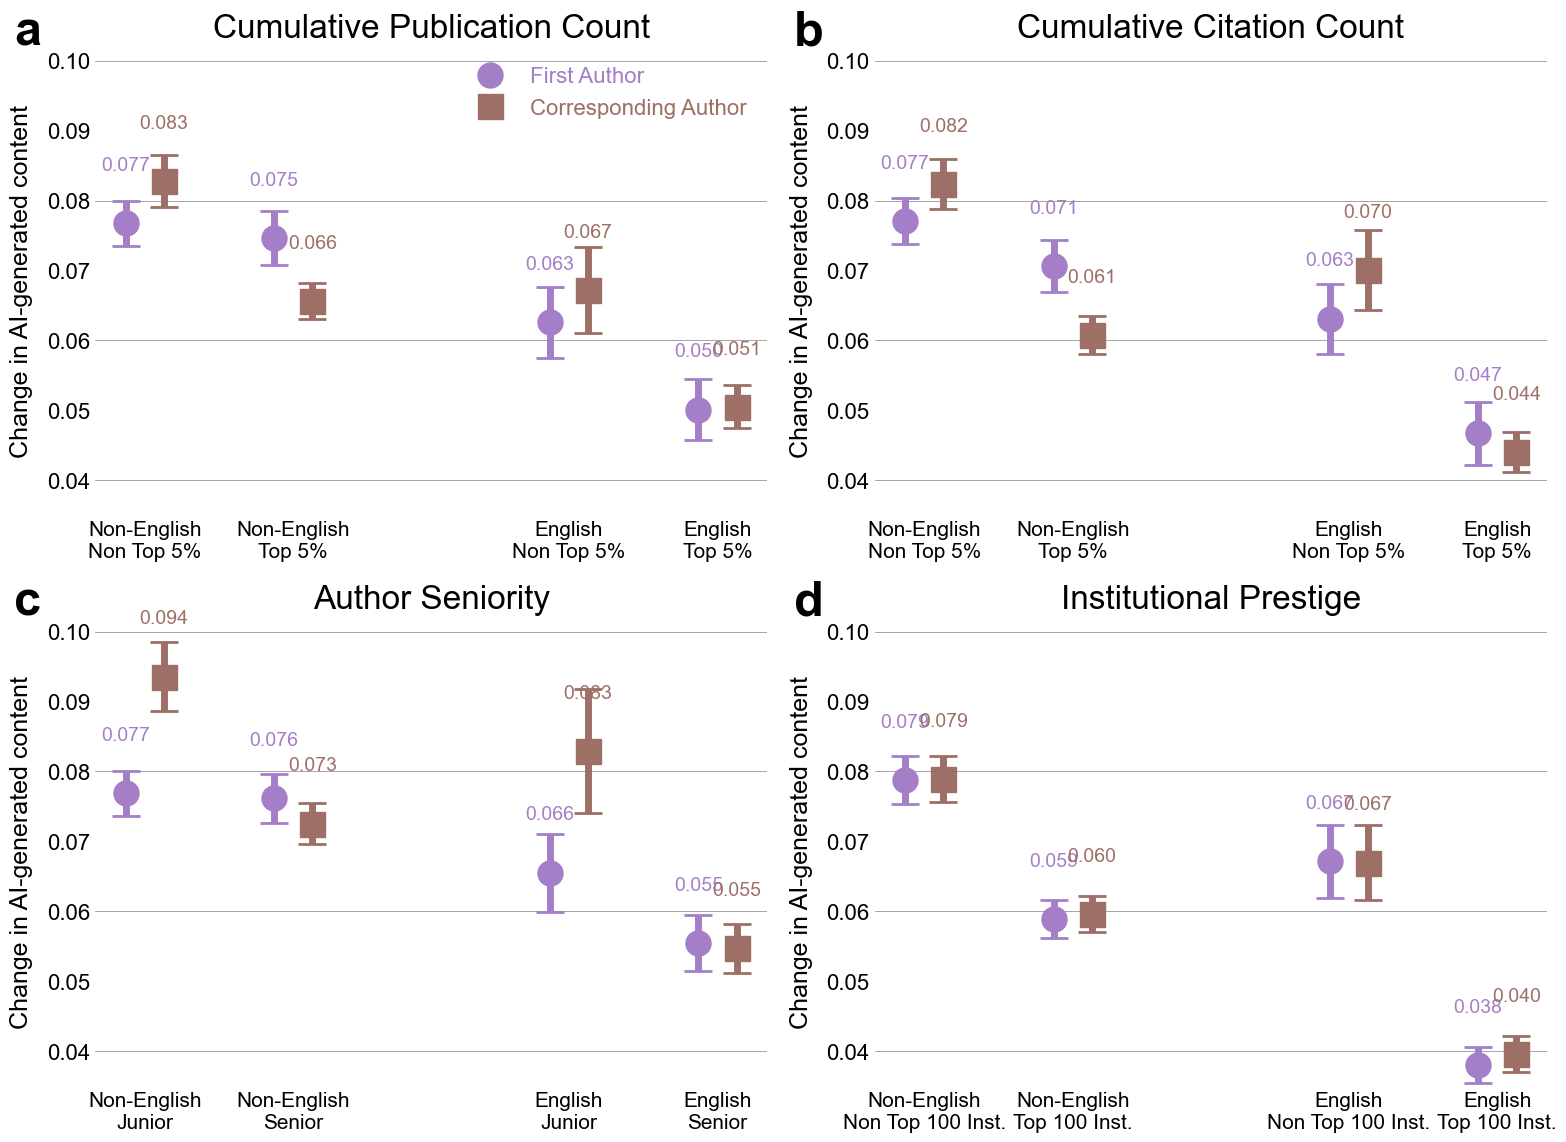

In [11]:
df = pd.read_csv('../../results/tables/group_ai_relative_change_name_nationality_journal_subfield_fe_intro_discussion.csv')

df_filtered = df[
    ((df['indicator'] == 'age') & (df['level'] == 15)) |
    ((df['indicator'] == 'pub') & (df['level'] == 5)) |
    ((df['indicator'] == 'cit') & (df['level'] == 5)) |
    ((df['indicator'] == 'ins') & (df['level'] == 100))
]

FONT_FAMILY = 'Arial'
FONT_SIZE_GLOBAL = 15
XTICK_LABEL_SIZE = 16
XTICK_ROTATION = 0
XTICK_HA = 'center'
YTICK_LABEL_SIZE = 16
XTICK_TICKSIZE = 15
Y_AXIS_LABEL_SIZE = 18
Y_AXIS_LABELPAD = 10
PANEL_LABEL_SIZE = 35
PANEL_LABEL_WEIGHT = 'bold'
VALUE_TEXT_SIZE = 14
TITLE_SIZE = 24
LEGEND_SIZE = 16
LEGEND_MARKERSIZE = 18

plt.rcParams['font.family'] = FONT_FAMILY
plt.rcParams['font.size'] = FONT_SIZE_GLOBAL

nrows, ncols = 2, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 12))
axes = axes.flatten()
panel_labels = ['a', 'b', 'c', 'd']  # For subplot labeling

def get_group_label(english, top, indicator):
    if indicator in ['pub', 'cit']:
        top_label = 'Top 5%' if top == 1 else 'Non Top 5%'
    elif indicator == 'age':
        top_label = 'Senior' if top == 1 else 'Junior'
    elif indicator == 'ins':
        top_label = 'Top 100 Inst.' if top == 1 else 'Non Top 100 Inst.'
    english_label = 'English' if english == 1 else 'Non-English'
    return english_label, top_label

order_color = {'first': "#a47ec7", 'last': "#9d6f66"}  # Colors for roles
order_marker = {'first': 'o', 'last': 's'}             # Marker shapes
order_label = {'first': 'First Author', 'last': 'Corresponding Author'} # Legend labels

indicators = ['pub', 'cit', 'age', 'ins']  # Panel order (columns of interest)
indicator_map = {
    'pub': 'Cumulative Publication Count',
    'cit': 'Cumulative Citation Count',
    'age': 'Author Seniority',
    'ins': 'Institutional Prestige'
}
x_pos_custom = [0, 0.7, 2, 2.7]

for idx, indicator in enumerate(indicators):
    ax = axes[idx]
    sub = df_filtered[df_filtered['indicator'] == indicator].copy()
    sub[['english_label', 'top_label']] = sub.apply(
        lambda x: pd.Series(get_group_label(x['english'], x['top'], indicator)), axis=1)
    sub['group'] = list(zip(sub['english_label'], sub['top_label']))

    if indicator in ['pub', 'cit']:
        group_order = [
            ('Non-English', 'Non Top 5%'),
            ('Non-English', 'Top 5%'),
            ('English', 'Non Top 5%'),
            ('English', 'Top 5%')
        ]
    elif indicator == 'age':
        group_order = [
            ('Non-English', 'Junior'),
            ('Non-English', 'Senior'),
            ('English', 'Junior'),
            ('English', 'Senior')
        ]
    elif indicator == 'ins':
        group_order = [
            ('Non-English', 'Non Top 100 Inst.'),
            ('Non-English', 'Top 100 Inst.'),
            ('English', 'Non Top 100 Inst.'),
            ('English', 'Top 100 Inst.')
        ]
    else:
        group_order = sorted(list(sub['author_profile_group'].unique()))
    xticklabels = [f"{en}\n{top}" for en, top in group_order]
    x_pos = np.array(x_pos_custom)
    width = 0.18

    for j, order in enumerate(['first', 'last']):
        data = sub[sub['order'] == order].copy()
        data = data.drop_duplicates(subset=['group'])
        data = data.set_index('group').reindex(group_order)
        coef = data['ai_post_relative_change'].values
        lower = data['lower'].values
        upper = data['upper'].values                
        err = [coef - lower, upper - coef]  
        x = x_pos + (j-0.5)*width
        ax.errorbar(
            x, coef, yerr=err, fmt=order_marker[order],
            color=order_color[order], capsize=10, linewidth=5, capthick=2, markersize=LEGEND_MARKERSIZE
        )
        for i, c in enumerate(coef):
            if not np.isnan(c):
                ax.text(
                    x[i], c+0.007, f'{c:.3f}', va='bottom',
                    ha='center', fontsize=VALUE_TEXT_SIZE, color=order_color[order]
                )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(xticklabels, fontsize=XTICK_LABEL_SIZE, rotation=XTICK_ROTATION, ha=XTICK_HA)
    ax.set_ylabel('Change in AI-generated content', fontsize=Y_AXIS_LABEL_SIZE, labelpad=Y_AXIS_LABELPAD)
    ax.text(
        -0.12, 1.08, panel_labels[idx], transform=ax.transAxes,
        fontsize=PANEL_LABEL_SIZE, fontweight=PANEL_LABEL_WEIGHT, va='top', ha='left'
    )

    ax.set_ylim(0.035, 0.102)
    ax.set_yticks([0.04,0.05,0.06,0.07, 0.08, 0.09,0.10])
    for y in np.arange(0, 0.11, 0.02):
        ax.axhline(y, color='gray', linestyle='-', linewidth=0.5, zorder=0)
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis='x', labelsize=XTICK_TICKSIZE, width=0, length=0)
    ax.tick_params(axis='y', labelsize=YTICK_LABEL_SIZE, width=0, length=0)

for idx, indicator in enumerate(indicators):
    axes[idx].set_title(indicator_map[indicator], fontsize=TITLE_SIZE, pad=7, loc='center')

if len(axes) > len(indicators):
    for k in range(len(indicators), len(axes)):
        fig.delaxes(axes[k])

legend_handles = [
    Line2D([0], [0], marker=order_marker['first'], color='w', markerfacecolor=order_color['first'],
           markeredgecolor=order_color['first'], markersize=LEGEND_MARKERSIZE, linewidth=0, label=order_label['first']),
    Line2D([0], [0], marker=order_marker['last'], color='w', markerfacecolor=order_color['last'],
           markeredgecolor=order_color['last'], markersize=LEGEND_MARKERSIZE, linewidth=0, label=order_label['last']),
]

legend_labels = [order_label['first'], order_label['last']]
legend_text_colors = [order_color['first'], order_color['last']]

leg = axes[0].legend(
    handles=legend_handles,
    labels=legend_labels,
    fontsize=LEGEND_SIZE,
    loc='upper right',
    frameon=False,
    handlelength=2,
    handler_map=None
)

for text, color in zip(leg.get_texts(), legend_text_colors):
    text.set_color(color)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Figure S10 Correlation between estimated fraction of AI-generated content and AI-detectors

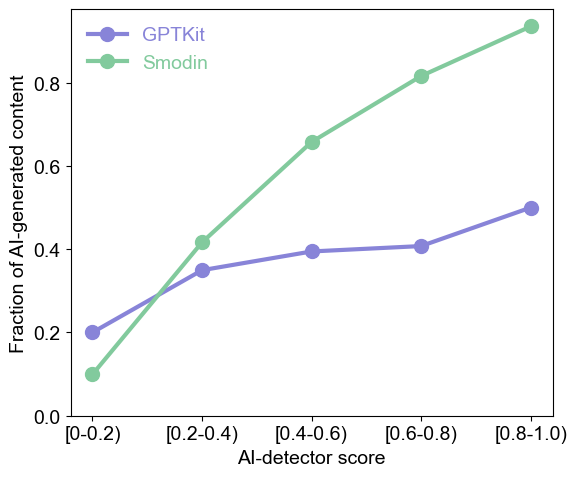

In [12]:
GPTKIT_COLOR = '#8884d8'
SMODIN_COLOR = '#82ca9d'
LINEWIDTH = 3
MARKERSIZE = 10

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 14

data1 = pd.read_csv('../../results/figure_data/data_figure_s10.csv')

plt.figure(figsize=(6, 5))

gptkit_line, = plt.plot(
    data1['score'], data1['GPTKit'],
    marker='o', label='GPTKit',
    color=GPTKIT_COLOR, linewidth=LINEWIDTH, markersize=MARKERSIZE
)

smodin_line, = plt.plot(
    data1['score'], data1['Smodin'],
    marker='o', label='Smodin',
    color=SMODIN_COLOR, linewidth=LINEWIDTH, markersize=MARKERSIZE
)

plt.xlabel('AI-detector score')
plt.ylabel('Fraction of AI-generated content')
plt.yticks([0,0.2,0.4,0.6,0.8])
legend = plt.legend(frameon=False)
for text, color in zip(legend.get_texts(), [GPTKIT_COLOR, SMODIN_COLOR]):
    text.set_color(color)

plt.tight_layout()
plt.show()

# Figure S11 Trends of AI-generated content for Introduction, Methods, Results, and Discussion

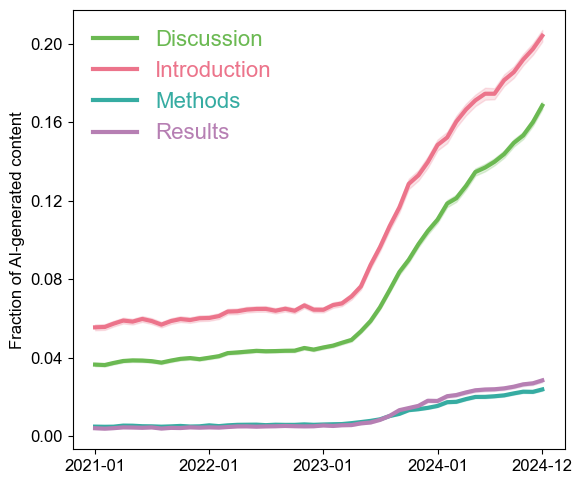

In [13]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12

LINEWIDTH = 3
SECTION_COLORS = ['#6bb952', '#ec748b', '#36aca2', '#b67fb3']

df = pd.read_csv('../../results/figure_data/data_figure_s11_4sections.csv')

date_mask = (df['accepted_year_month'] >= '2021-01') & (df['accepted_year_month'] <= '2024-12')
plot_data = df[date_mask].dropna(subset=['mean'])

sections = plot_data['section'].unique()
section_legend_names = {}
for sec in sections:
    if sec == 'discussion':
        section_legend_names[sec] = 'Discussion'
    elif sec == 'intro':
        section_legend_names[sec] = 'Introduction'
    elif sec == 'results':
        section_legend_names[sec] = 'Results'
    elif sec == 'method':
        section_legend_names[sec] = 'Methods'
    else:
        section_legend_names[sec] = sec

plt.figure(figsize=(6, 5))
lines = []
for idx, sec in enumerate(sections):
    color = SECTION_COLORS[idx % len(SECTION_COLORS)]
    sec_data = plot_data[plot_data['section'] == sec].copy()
    sec_data = sec_data.sort_values('accepted_year_month')
    x = pd.to_datetime(sec_data['accepted_year_month'])
    y = sec_data['mean']
    y1 = sec_data['ci_lower']
    y2 = sec_data['ci_upper']
    line, = plt.plot(
        x, y,
        label=section_legend_names[sec], linewidth=LINEWIDTH, color=color
    )
    lines.append(line)
    plt.fill_between(
        x, y1, y2,
        color=color, alpha=0.2
    )

plt.ylabel('Fraction of AI-generated content', fontname='Arial', fontsize=12)
legend = plt.legend(frameon=False, fontsize=16)
for text, line in zip(legend.get_texts(), lines):
    text.set_color(line.get_color())

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
xtick_labels = ['2021-01', '2022-01', '2023-01', '2024-01',  '2024-12']
xtick_locs = pd.to_datetime(xtick_labels)
plt.xticks(xtick_locs, xtick_labels, fontname='Arial', fontsize=12)
plt.yticks([0,0.04,0.08,0.12,0.16,0.20])
plt.tight_layout()
plt.show()
